In [1]:
import os
import torch
torch.set_default_dtype(torch.double)

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.distributions.starflow import StarFlowDistribution
from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.product import ProductDistribution
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean
from src.training.starflow import StarFlowTraining
from src.training.star_gaussian import StarGaussianTraining
from src.transforms.vector.parity.simple_tanh import SimpleTanhParityVectorTransform
from src.transforms.vector.linear.lower_triangular import LowerTriangularLinearVectorTransform
from src.transforms.vector.linear.upper_triangular import UpperTriangularLinearVectorTransform

results_folder = os.path.join("results", "tree", "starflow")
# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


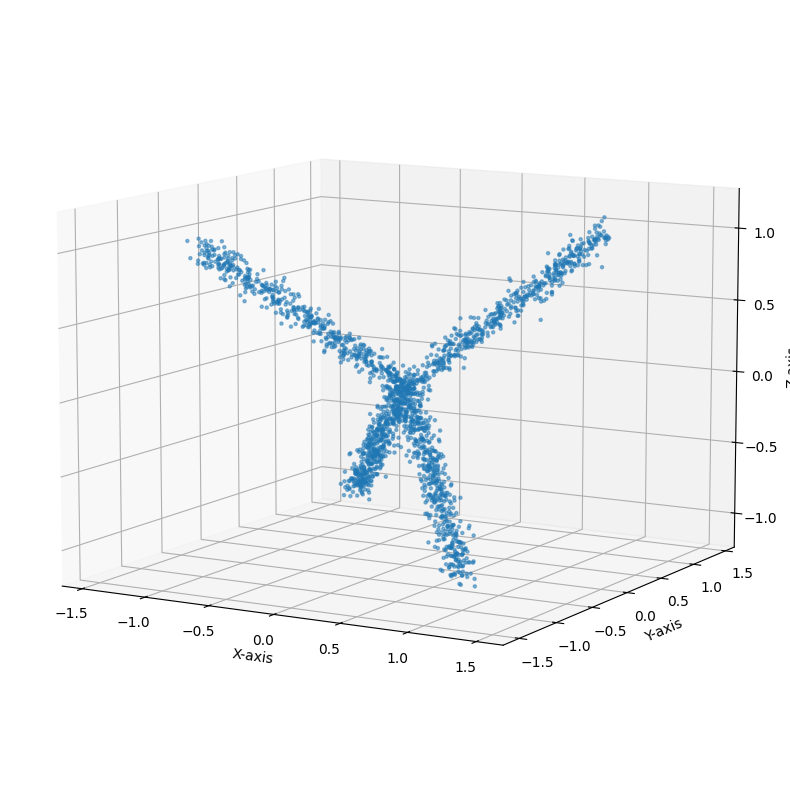

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [4]:
# construct transform diffeomorphism
class SimpleStarFlowVectorDiffeomorphism(StarFlowVectorDiffeomorphism):
    def __init__(self, dim, hidden_dim, n_flows, num_radials):
        super(SimpleStarFlowVectorDiffeomorphism, self).__init__(dim, StarFlowDistribution(self.create_transform(dim, hidden_dim, n_flows), self.create_star_gaussian(dim, num_radials)))

    def create_transform(self, dim, hidden_dim, n_flows):
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(UpperTriangularLinearVectorTransform(dim))
            transforms_list.append(LowerTriangularLinearVectorTransform(dim))
            transforms_list.append(SimpleTanhParityVectorTransform(dim, hidden_dim, parity=i))
        transforms_list.append(UpperTriangularLinearVectorTransform(dim))
        transforms_list.append(LowerTriangularLinearVectorTransform(dim))
        transform = transforms.CompositeTransform(transforms_list)
        return transform
    
    def create_star_gaussian(self, dim, num_radials):
        return MultiInverseLinearStarNormGaussianDistribution(dim, num_radials)

# construct transform diffeomorphism trainer
dim = 3
hidden_dim = 8
n_flows = 2
num_radials = 2
    
# instantiate GME-informed star flow
starflow_trainer = StarFlowTraining(SimpleStarFlowVectorDiffeomorphism(dim, hidden_dim, n_flows, num_radials), lr=1e-3)

Using StarGaussianVectorDiffeomorphism for radial component of StarFlowVectorDiffeomorphism


Flow Epoch 1/2000, Loss: 7.812245


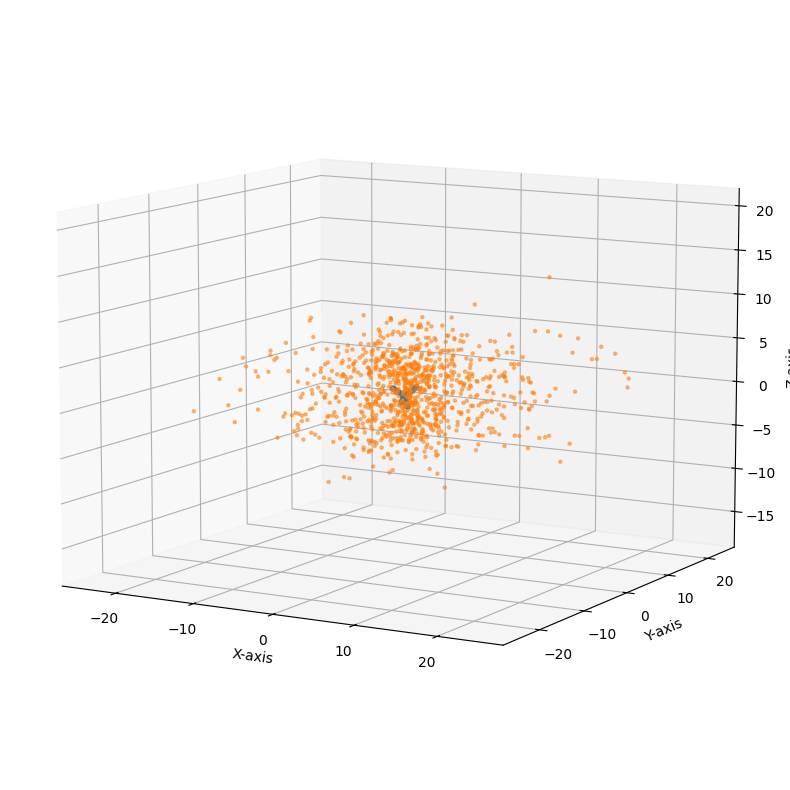

Flow Epoch 200/2000, Loss: 1.453448


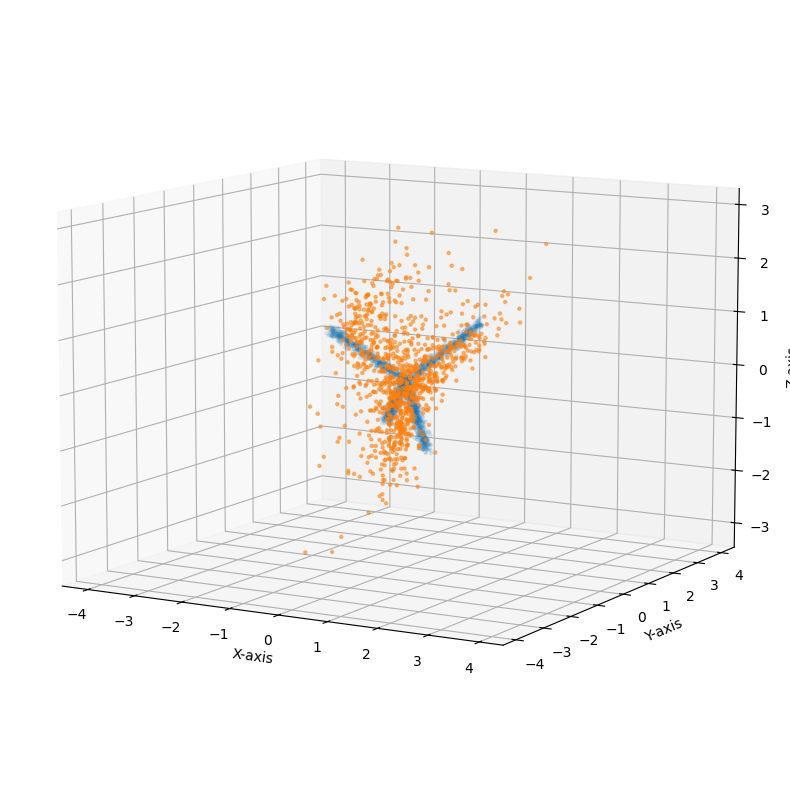

Flow Epoch 400/2000, Loss: 0.398761


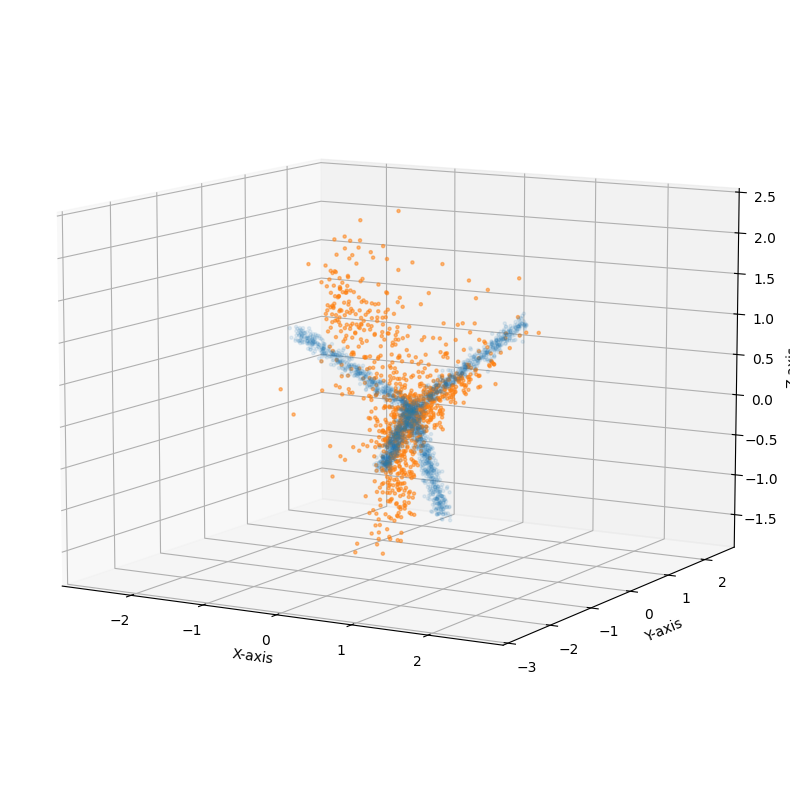

Flow Epoch 600/2000, Loss: 0.193437


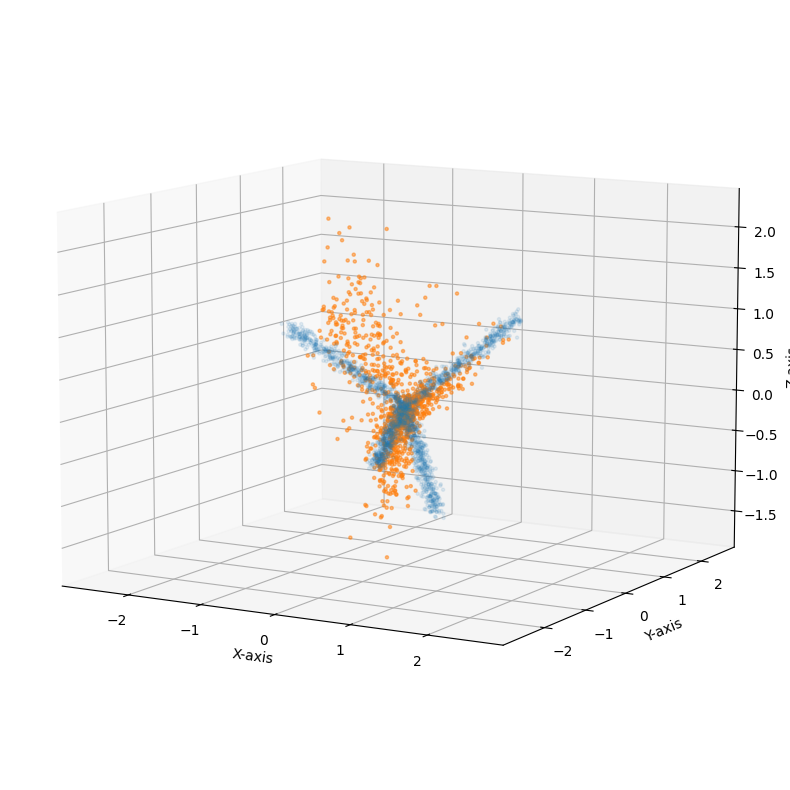

Flow Epoch 800/2000, Loss: -0.082518


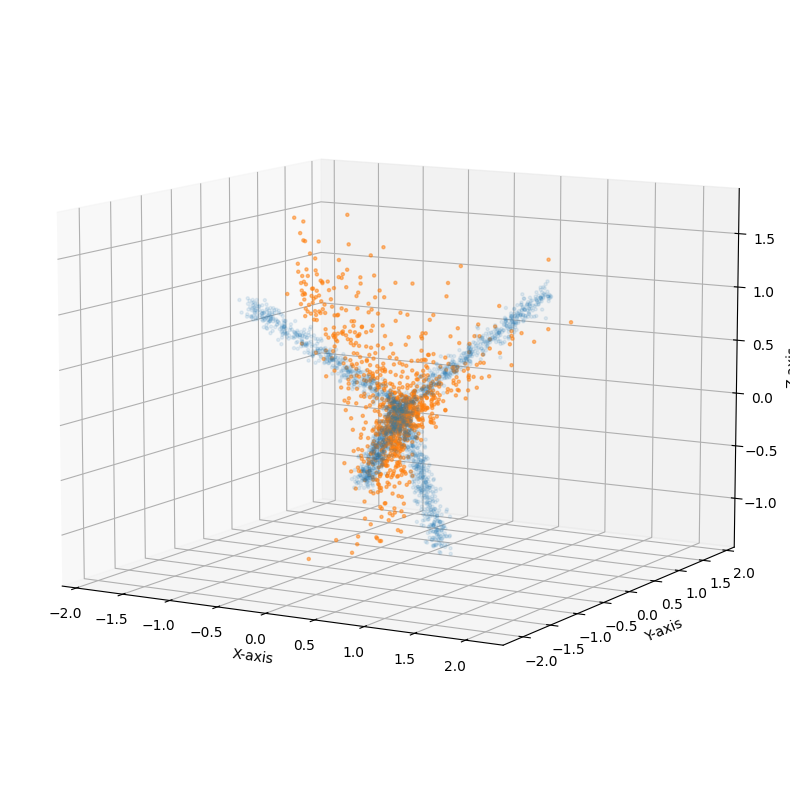

Flow Epoch 1000/2000, Loss: -0.406698


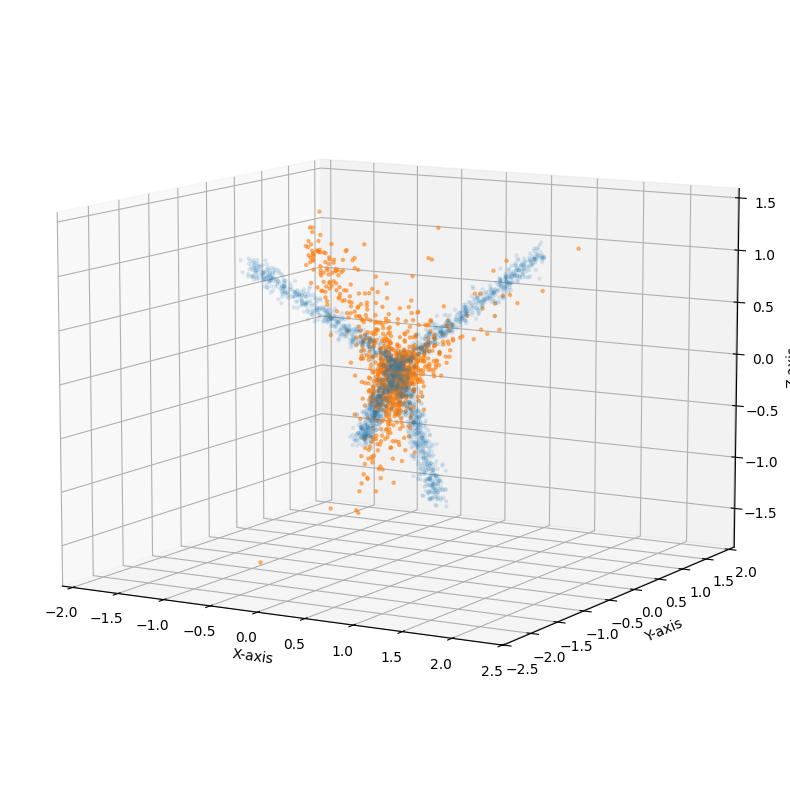

Flow Epoch 1200/2000, Loss: -0.597629


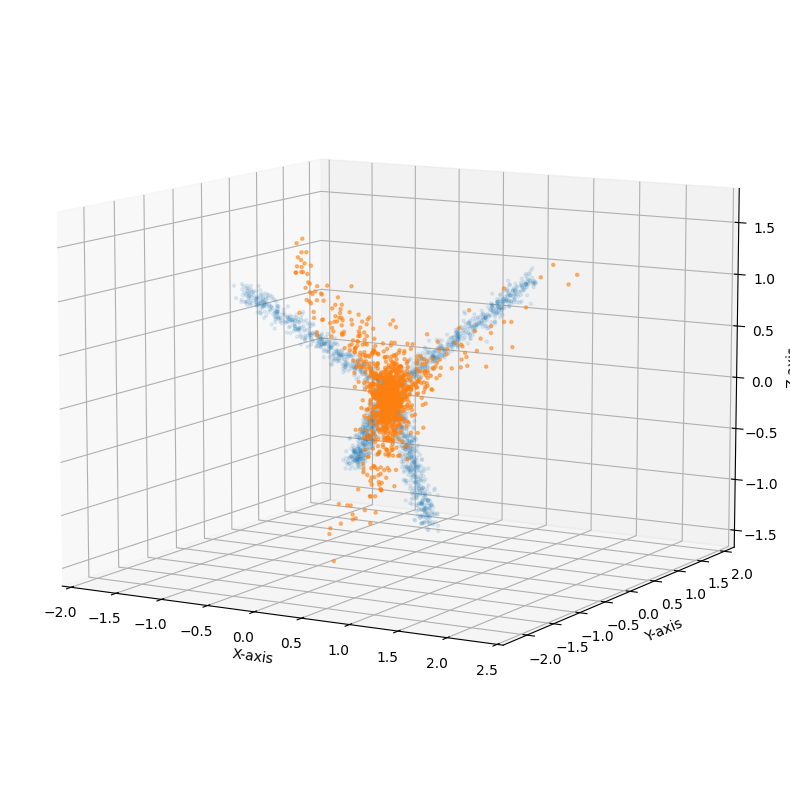

Flow Epoch 1400/2000, Loss: -0.710582


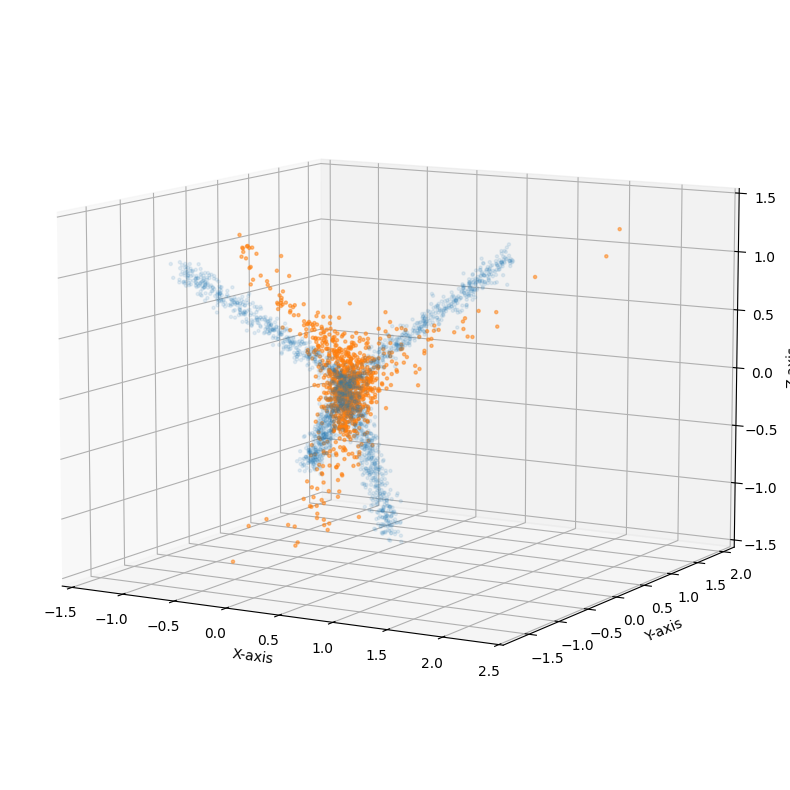

Flow Epoch 1600/2000, Loss: -0.786393


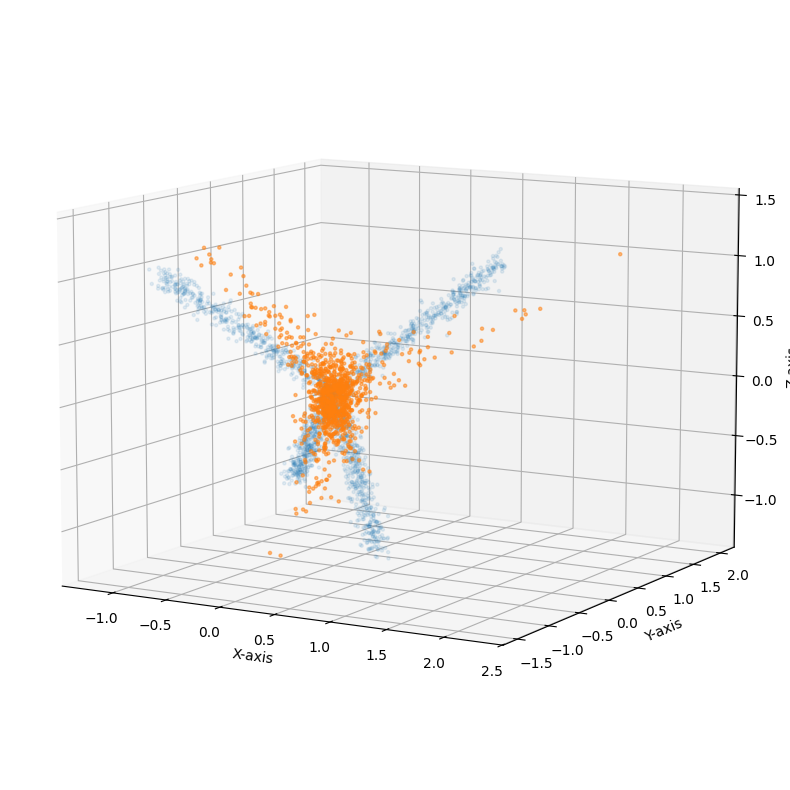

Flow Epoch 1800/2000, Loss: -0.798144


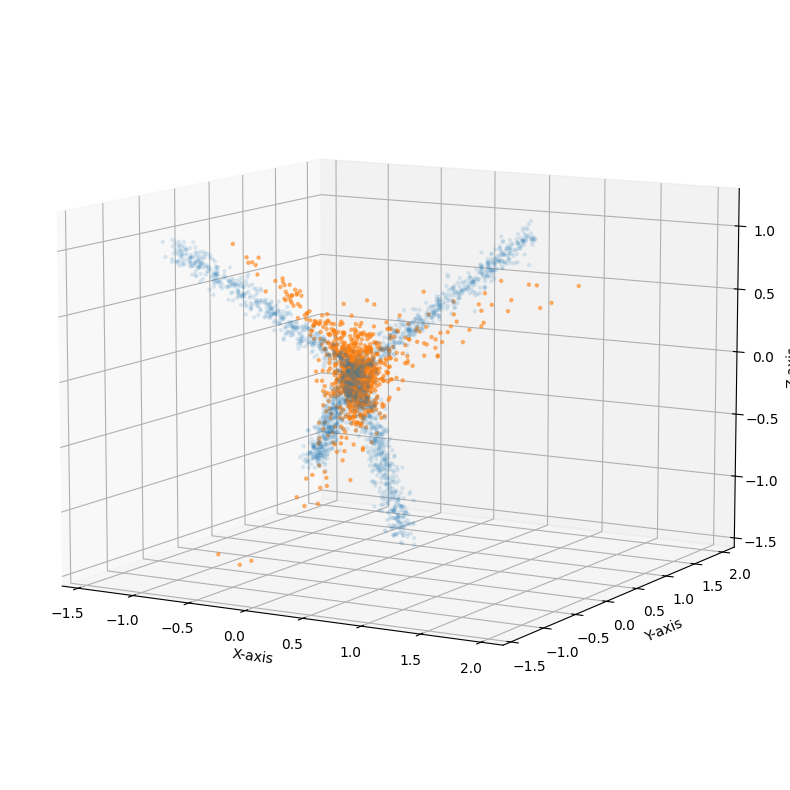

Flow Epoch 2000/2000, Loss: -0.823643


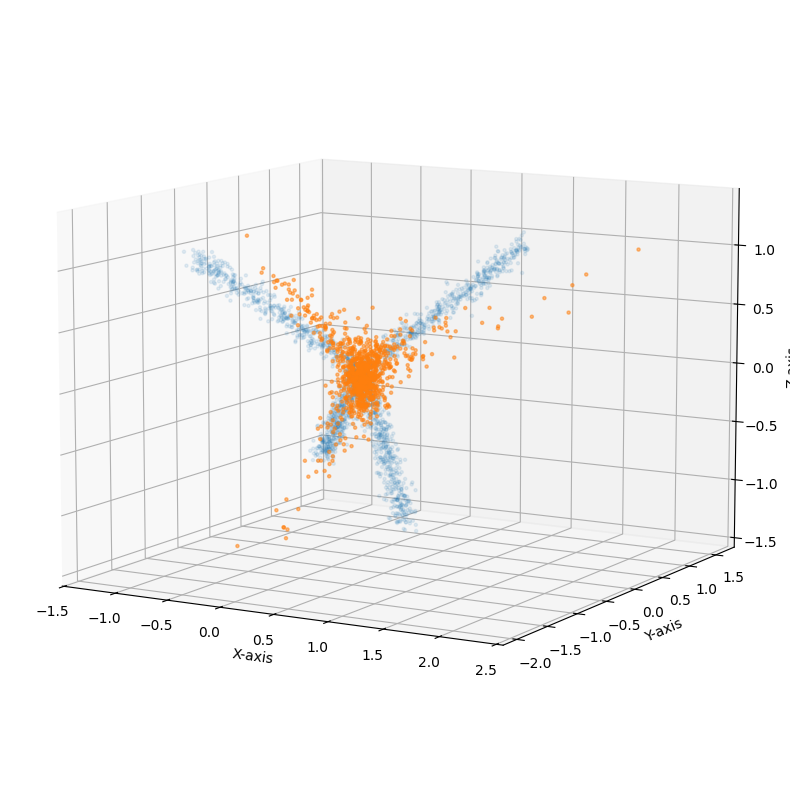

In [5]:
# construct train loop for the decoding diffeomorphism
num_epochs_flow = 2000
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        loss = starflow_trainer.train_step(x)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    if (epoch + 1) % (num_epochs_flow // 10) == 0 or epoch == 0:
        print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")
        with torch.no_grad():
            samples = starflow_trainer.starflow_diffeo.starflow.sample(1000)
        
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1, label='Data')
        ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5, label='Samples')
        ax.set_xlabel("X-axis")
        ax.set_ylabel("Y-axis")
        ax.set_zlabel("Z-axis")
        plt.axis('equal')
        ax.view_init(elev=10)
        plt.tight_layout()
        plt.savefig(os.path.join(results_folder,f"starflow_samples_epoch_{epoch+1}.png"))
        plt.show()

phi = starflow_trainer.phi
psi_o_phi = starflow_trainer.psi_o_phi

In [6]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackVectorEuclidean(phi)
# construct iso_manifold
iso_phi_manifold = l2IsometrizedVectorEuclidean(phi_manifold)

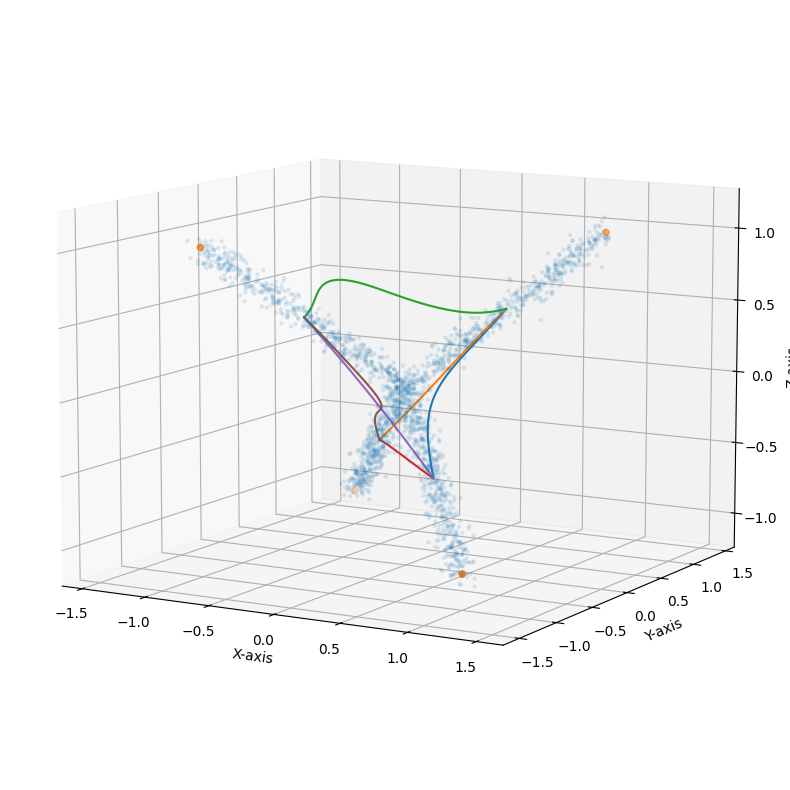

In [7]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
scale = 0.5
with torch.no_grad():
    phi_geodesics = iso_phi_manifold.geodesic(scale * data_clusters[None], scale * data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_geodesics[0, i, j, :, 0].numpy(), phi_geodesics[0, i, j, :, 1].numpy(), phi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_geodesics.png"))
plt.show()

In [8]:
# # compute data barycentre
# phi_barycentre_data = iso_phi_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# # tangent space PCA to find principal directions at data barycentre
# l2_pga_solver_phi_bary = l2TangentSpacePCAVectorSolver(data, iso_phi_manifold, phi_barycentre_data)
# # compute principal directions
# _, phi_compressed_data, _ = l2_pga_solver_phi_bary.solve(2)

# # plot compressed data in 3D
# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')
# # plot original data
# ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# # plot compressed data
# ax.scatter(phi_compressed_data[:, 0].numpy(), phi_compressed_data[:, 1].numpy(), phi_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# # plot barycentre
# ax.scatter(phi_barycentre_data[0].item(), phi_barycentre_data[1].item(), phi_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
# ax.set_xlabel("X-axis")
# ax.set_ylabel("Y-axis")
# ax.set_zlabel("Z-axis")
# plt.axis('equal')
# ax.view_init(elev=10)
# plt.tight_layout()
# plt.savefig(os.path.join(results_folder,"data_phi_compressed.png"))
# plt.show()

# # compute error between original data and compressed data
# rel_error = (torch.norm(data - phi_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
# print("Mean reconstruction error after compression:", rel_error)

In [9]:
# construct manifold from learned flow
phi_psi_manifold = StandardPullbackVectorEuclidean(psi_o_phi)
# construct iso_manifold 
iso_phi_psi_manifold = l2IsometrizedVectorEuclidean(phi_psi_manifold)

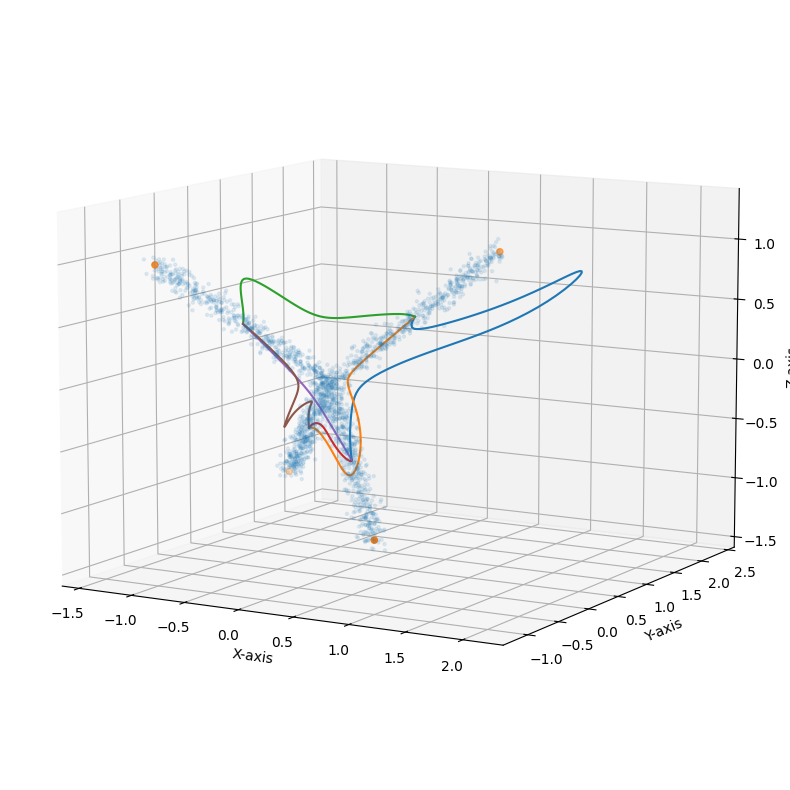

In [10]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    phi_psi_geodesics = iso_phi_psi_manifold.geodesic(scale * data_clusters[None], scale * data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_psi_geodesics[0, i, j, :, 0].numpy(), phi_psi_geodesics[0, i, j, :, 1].numpy(), phi_psi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_psi_geodesics.png"))
plt.show()

iteration 1 | error = 0.03484826846842432
iteration 2 | error = 0.03395778533002229
iteration 3 | error = 0.03380100074337325
iteration 4 | error = 0.02843756588205922
iteration 5 | error = 0.022843771320601516
iteration 6 | error = 0.019726759930684346
iteration 7 | error = 0.015874387484605176
iteration 8 | error = 0.014126486896326099
iteration 9 | error = 0.011281570280692751
iteration 10 | error = 0.009543021013195175
iteration 11 | error = 0.007519034972569938
iteration 12 | error = 0.006198471056661315
iteration 13 | error = 0.004848566934756594
iteration 14 | error = 0.003934307164052215
iteration 15 | error = 0.003069908584531617
iteration 16 | error = 0.002466933145696275
iteration 17 | error = 0.0019253648757066833
iteration 18 | error = 0.0015377935290421755
iteration 19 | error = 0.0012018788854901673
iteration 20 | error = 0.000956163673107703
gradient descent was terminated after reaching a error 0.000956163673107703 in 20 iterations
Computing rank 2 approximation on tan

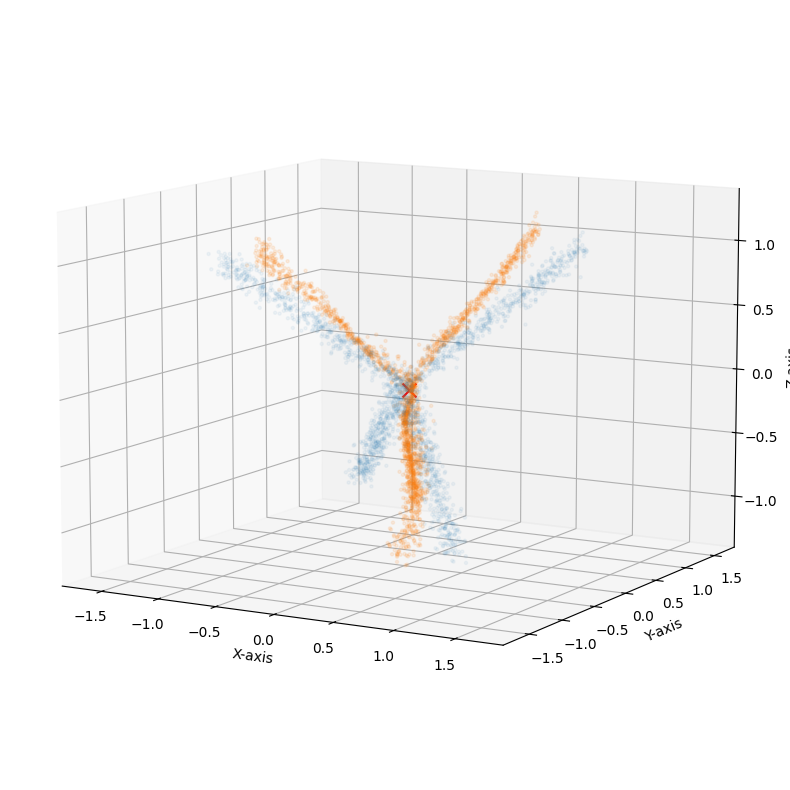

Mean reconstruction error after compression: 0.2608681256555044


In [11]:
# compute data barycentre
phi_psi_barycentre_data = iso_phi_psi_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_phi_psi_bary = l2TangentSpacePCAVectorSolver(data, iso_phi_psi_manifold, phi_psi_barycentre_data)
# compute principal directions
_, phi_psi_compressed_data, _ = l2_pga_solver_phi_psi_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(phi_psi_compressed_data[:, 0].numpy(), phi_psi_compressed_data[:, 1].numpy(), phi_psi_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(phi_psi_barycentre_data[0].item(), phi_psi_barycentre_data[1].item(), phi_psi_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_psi_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - phi_psi_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

In [12]:
# compare embeddings
phi_psi_pca_embedding = l2_pga_solver_phi_psi_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(phi_psi_pca_embedding[:, 0], phi_psi_pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"phi_psi_emb_comparison.png"))
plt.show()

NameError: name 'embeddings_centered' is not defined

<Figure size 800x800 with 0 Axes>